In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [3]:
from utils.plot_style import set_plot_style 
set_plot_style()

# Plot Traces

In [5]:
# Folder
path_folder_data = r"./data/spectrumanalyser/spectrum_trace/2026-08-04_pda36a_001/"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)
# Run names
name_exp = 'spectrum_trace_pda36a'
# List all files in the folder
folder_data_files = os.listdir(path_folder_data + '/' + name_exp)
print(folder_data_files)

['spectrum_trace_pda36a', 'temp.json']
['2026_08_04__16_57_30__spectrum_trace_pda36a.h5']


In [6]:
name = folder_data_files[0]  # take the first file in the folder

full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

data = aqm.data
print(data)

INFO:2026_08_04__16_57_30__spectrum_trace_pda36a


AnalysisData (rw) (not saved): 
 {
    "acquisition_cell" (r): {
        "1": "variable of type str"
    },
    "experiment_name" (r): "variable of type str",
    "info" (r): {
        "acquisition_duration": "0.260 (type : float64)",
        "logs": "variable of type str",
        "prints": "variable of type str"
    },
    "traces" (r): "variable of type dict",
    "useful" (r): "variable of type bool"
}


In [12]:
print(keys := data["traces"].keys())

dict_keys(['TRACE1', 'TRACE2', 'TRACE3', 'TRACE4', 'TRACE5', 'TRACE6'])


In [ ]:
# Need to remember what are the traces name w.r.t the experiment/measurement done

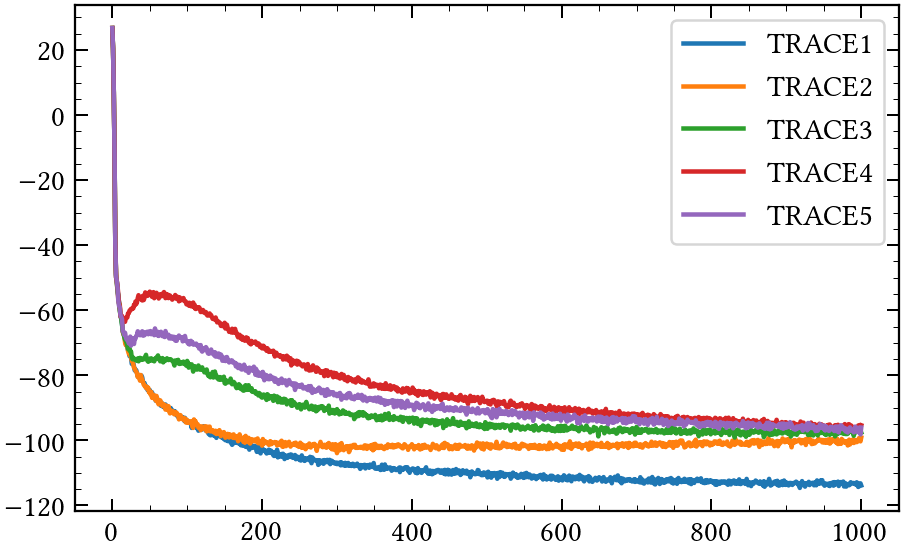

In [13]:
plt.figure()

for name, trace in data["traces"].items():
    trace = np.asarray(trace)
    if np.std(trace) < 1e-3:   # skip flat traces
        continue
    plt.plot(trace, label=name)

plt.legend()
plt.show()